In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("JobRole.csv")

In [4]:
df.columns

Index(['Degree', 'Major', 'Specialization', 'CGPA', 'Skills', 'Certification',
       'Years of Experience', 'Preferred Industry', 'Job Role'],
      dtype='object')

In [5]:
df.head()

,Degree,Major,Specialization,CGPA,Skills,Certification,Years of Experience,Preferred Industry,Job Role
0,M.Tech,Computer Science,Frontend Development,8.70,"HTML, CSS, JavaScript",HackerRank SQL,3.0,Product-based,Web Developer
1,B.E,Computer Science,Full Stack Development,9.99,"HTML, CSS, JavaScript",Google Cloud Basics,1.5,Software Development,Web Developer
2,B.E,Computer Science,Frontend Development,7.55,"HTML, CSS, JavaScript",Google Cloud Basics,2.0,Tech Consulting,Web Developer
3,M.Tech,AI & ML,Full Stack Development,7.26,"React, Node.js, MongoDB",NPTEL Python,1.0,Software Development,Web Developer
4,MCA,Computer Science,React Development,9.37,"React, Node.js, MongoDB",NPTEL Python,2.0,Tech Consulting,Web Developer


In [6]:
df.tail()

,Degree,Major,Specialization,CGPA,Skills,Certification,Years of Experience,Preferred Industry,Job Role
2095,M.Sc,Mathematics,Deep Learning,6.83,"Python, NLP, Reinforcement Learning, Cloud Dep...","Azure AI Engineer, Coursera ML by Andrew Ng",4.0,Finance,ML Engineer
2096,MCA,Data Science,Big Data,9.29,"Python, Scikit-learn, ML Ops, PyTorch, Feature...","Deep Learning Specialization, IBM Data Science...",5.0,IT,ML Engineer
2097,MCA,Electronics,Data Analytics,6.75,"Python, TensorFlow, Keras, Deep Learning, Neur...",AWS ML Specialty,0.0,IT,ML Engineer
2098,M.Tech,Electronics,Machine Learning,7.62,"Python, NLP, Reinforcement Learning, Cloud Dep...",TensorFlow Developer,2.0,Finance,ML Engineer
2099,M.Tech,Mathematics,Data Analytics,9.16,"Python, Scikit-learn, ML Ops, PyTorch, Feature...","TensorFlow Developer, Google Data Analytics",3.0,E-commerce,ML Engineer


In [7]:
# shape of the dataset

df.shape

(2100, 9)

In [8]:
# getting information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2100 entries, 0 to 2099
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Degree               2100 non-null   object 
 1   Major                2100 non-null   object 
 2   Specialization       2100 non-null   object 
 3   CGPA                 2100 non-null   float64
 4   Skills               2100 non-null   object 
 5   Certification        2039 non-null   object 
 6   Years of Experience  2100 non-null   float64
 7   Preferred Industry   2100 non-null   object 
 8   Job Role             2100 non-null   object 
dtypes: float64(2), object(7)
memory usage: 147.8+ KB


In [9]:
# finding the null values

df.isnull().sum()

Degree                  0
Major                   0
Specialization          0
CGPA                    0
Skills                  0
Certification          61
Years of Experience     0
Preferred Industry      0
Job Role                0
dtype: int64

In [10]:
df.isnull().sum()/df.shape[0]*100

Degree                 0.000000
Major                  0.000000
Specialization         0.000000
CGPA                   0.000000
Skills                 0.000000
Certification          2.904762
Years of Experience    0.000000
Preferred Industry     0.000000
Job Role               0.000000
dtype: float64

In [11]:
#finding duplicates

df.duplicated().sum()

np.int64(0)

In [12]:
#  garbage values
for i in df.select_dtypes(include="object").columns :
    print(df[i].value_counts())
    print("***"*10)

Degree
B.Tech          410
M.Tech          245
MCA             173
BCA             165
BBA             161
MBA             155
M.Sc            132
B.Sc            126
B.E             126
B.Com            96
BA Economics     59
BA               47
B.Des            31
BFA              26
MA               25
M.Ed             23
MSc              22
PhD              20
B.Ed             16
M.Com            16
M.Des            13
BSc              13
Name: count, dtype: int64
******************************
Major
Information Technology     289
Computer Science           288
Data Science               181
AI & ML                    130
Business Administration    127
Electronics                126
Finance                    109
Economics                  101
Software Engineering        71
Marketing                   69
Mathematics                 68
Management                  57
Electrical Engineering      52
Accounting                  52
Network Security            39
Applied Arts             

In [13]:

#EDA

df.describe

<bound method NDFrame.describe of       Degree             Major          Specialization  CGPA  \
0     M.Tech  Computer Science    Frontend Development  8.70   
1        B.E  Computer Science  Full Stack Development  9.99   
2        B.E  Computer Science    Frontend Development  7.55   
3     M.Tech           AI & ML  Full Stack Development  7.26   
4        MCA  Computer Science       React Development  9.37   
...      ...               ...                     ...   ...   
2095    M.Sc       Mathematics           Deep Learning  6.83   
2096     MCA      Data Science                Big Data  9.29   
2097     MCA       Electronics          Data Analytics  6.75   
2098  M.Tech       Electronics        Machine Learning  7.62   
2099  M.Tech       Mathematics          Data Analytics  9.16   

                                                 Skills  \
0                                 HTML, CSS, JavaScript   
1                                 HTML, CSS, JavaScript   
2                   

In [14]:
df.describe(include="object")

,Degree,Major,Specialization,Skills,Certification,Preferred Industry,Job Role
count,2100,2100,2100,2100,2039,2100,2100
unique,22,34,67,790,539,41,15
top,B.Tech,Information Technology,Data Analytics,"Python, R, Data Visualization, SQL, TensorFlow...",Google Data Analytics,IT Services,Web Developer
freq,410,289,140,57,59,149,150


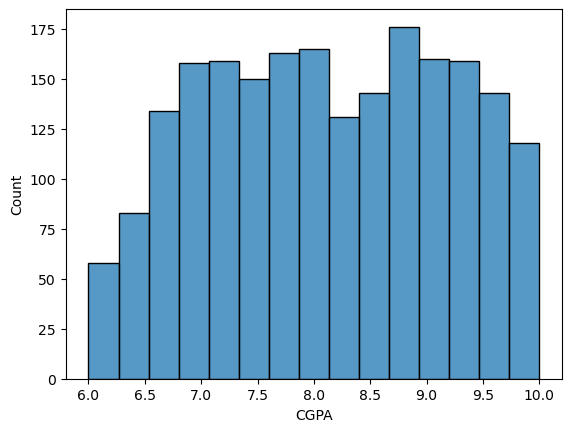

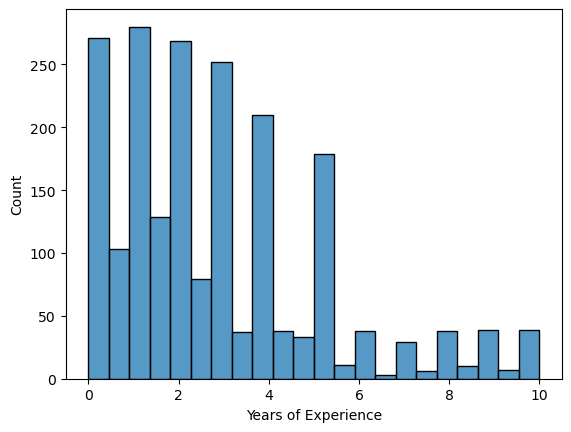

In [15]:
for i in df.select_dtypes(include="number").columns :
    sns.histplot(data=df,x=i)
    plt.show()

In [16]:
# missing value treatment

df["Certification"] = df["Certification"].fillna("None")


In [17]:
df.isnull().sum()

Degree                 0
Major                  0
Specialization         0
CGPA                   0
Skills                 0
Certification          0
Years of Experience    0
Preferred Industry     0
Job Role               0
dtype: int64

In [18]:
# remove outliers

In [19]:
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

df = remove_outliers(df, "Years of Experience")
df = remove_outliers(df, "CGPA")


In [20]:
df.shape


(2009, 9)

In [21]:
# encode Categorical Columns (Convert text → numbers)

In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    "Degree",
    "Major",
    "Specialization",
    "Skills",
    "Certification",
    "Preferred Industry",
    "Job Role"
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])


In [23]:
df.head()


,Degree,Major,Specialization,CGPA,Skills,Certification,Years of Experience,Preferred Industry,Job Role
0,16,10,28,8.70,333,314,3.0,28,14
1,2,10,29,9.99,333,275,1.5,32,14
2,2,10,28,7.55,333,275,2.0,36,14
3,16,0,29,7.26,540,403,1.0,32,14
4,19,10,52,9.37,540,403,2.0,36,14


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[["CGPA", "Years of Experience"]] = scaler.fit_transform(
    df[["CGPA", "Years of Experience"]]
)


In [25]:
df.head

<bound method NDFrame.head of       Degree  Major  Specialization      CGPA  Skills  Certification  \
0         16     10              28  0.554328     333            314   
1          2     10              29  1.774725     333            275   
2          2     10              28 -0.533623     333            275   
3         16      0              29 -0.807975     540            403   
4         19     10              52  1.188178     540            403   
...      ...    ...             ...       ...     ...            ...   
2095      15     26              20 -1.214774     509             38   
2096      19     12               4  1.112494     531            212   
2097      19     18              18 -1.290458     537              2   
2098      16     18              39 -0.467400     509            501   
2099      16     26              18  0.989509     531            512   

      Years of Experience  Preferred Industry  Job Role  
0                0.233920                  28  

In [26]:
from sklearn.model_selection import train_test_split

# X = features, y = target
X = df.drop("Job Role", axis=1)
y = df["Job Role"]

# splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((1607, 8), (402, 8))

In [27]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestClassifier(n_estimators=200, random_state=42)

In [28]:
from sklearn.metrics import accuracy_score

pred = model.predict(X_test)
acc = accuracy_score(y_test, pred)

acc


0.8432835820895522

In [29]:
# X = features, y = target
X = df.drop("Job Role", axis=1)
y = df["Job Role"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "SVM": SVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc

results


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Logistic Regression': 0.26119402985074625,
 'KNN': 0.6119402985074627,
 'Decision Tree': 0.8333333333333334,
 'Random Forest': 0.8482587064676617,
 'SVM': 0.23134328358208955}

In [31]:
# Example new student data
new_data = {
    "Degree": [10],
    "Major": [16],
    "Specialization": [25],
    "CGPA": [7.8],
    "Skills": [333],
    "Certification": [275],
    "Years of Experience": [1.5],
    "Preferred Industry": [28]
}

import pandas as pd
new_df = pd.DataFrame(new_data)

# scale numerical columns
new_df[["CGPA", "Years of Experience"]] = scaler.transform(
    new_df[["CGPA", "Years of Experience"]]
)

prediction = model.predict(new_df)
prediction


array([10])

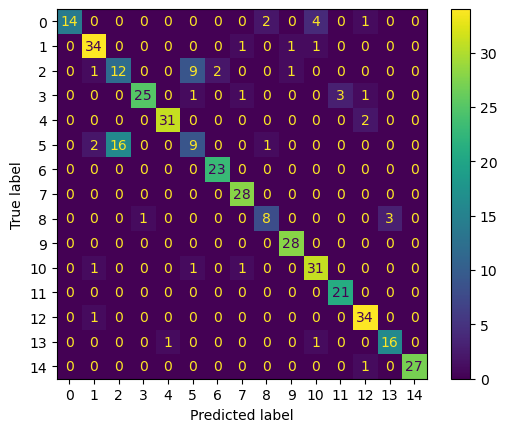

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# predict using best model (Random Forest)
rf_preds = models["Random Forest"].predict(X_test)

cm = confusion_matrix(y_test, rf_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()


In [33]:
from sklearn.metrics import classification_report
print(classification_report(y_test, rf_preds))


              precision    recall  f1-score   support

           0       1.00      0.67      0.80        21
           1       0.87      0.92      0.89        37
           2       0.43      0.48      0.45        25
           3       0.96      0.81      0.88        31
           4       0.97      0.94      0.95        33
           5       0.45      0.32      0.38        28
           6       0.92      1.00      0.96        23
           7       0.90      1.00      0.95        28
           8       0.73      0.67      0.70        12
           9       0.93      1.00      0.97        28
          10       0.84      0.91      0.87        34
          11       0.88      1.00      0.93        21
          12       0.87      0.97      0.92        35
          13       0.84      0.89      0.86        18
          14       1.00      0.96      0.98        28

    accuracy                           0.85       402
   macro avg       0.84      0.84      0.83       402
weighted avg       0.85   

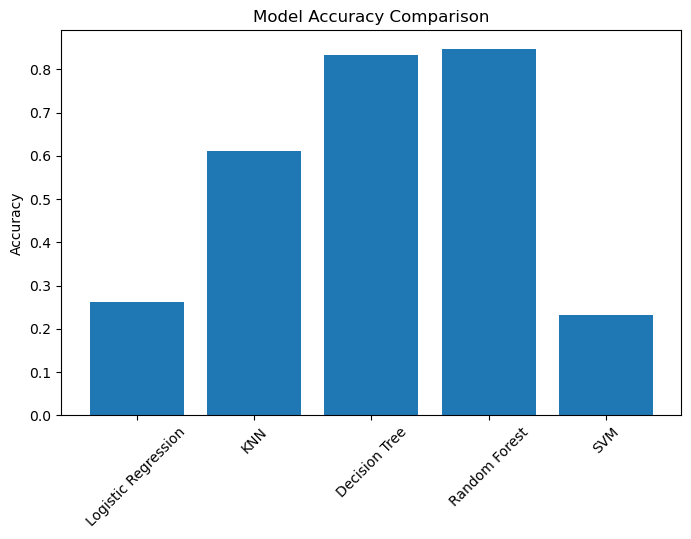

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values())
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()


In [36]:
import joblib

joblib.dump(models["Random Forest"], "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

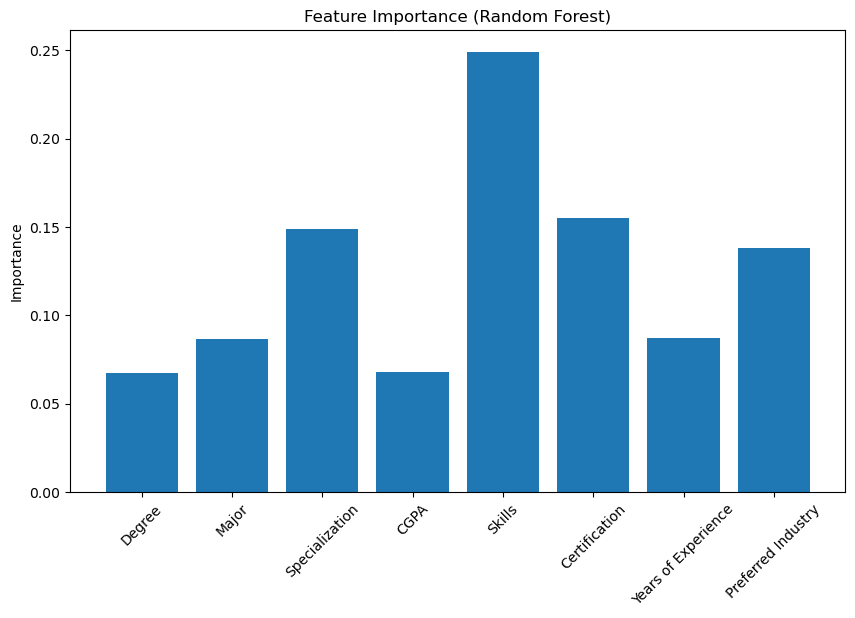

In [40]:
# visualization



import numpy as np

importances = models["Random Forest"].feature_importances_
features = X_train.columns

plt.figure(figsize=(10,6))
plt.bar(features, importances)
plt.xticks(rotation=45)
plt.ylabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.show()


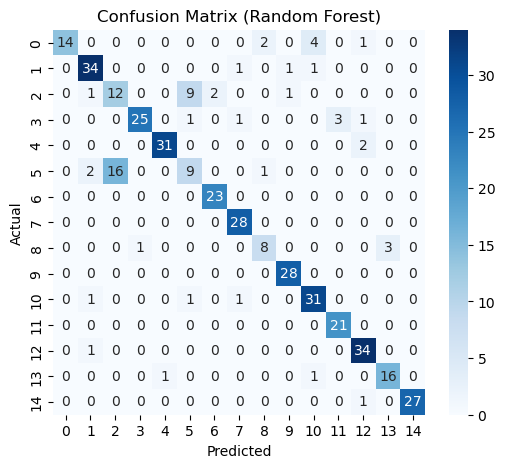

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

rf_preds = models["Random Forest"].predict(X_test)
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Random Forest)")
plt.show()


In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_preds))


              precision    recall  f1-score   support

           0       1.00      0.67      0.80        21
           1       0.87      0.92      0.89        37
           2       0.43      0.48      0.45        25
           3       0.96      0.81      0.88        31
           4       0.97      0.94      0.95        33
           5       0.45      0.32      0.38        28
           6       0.92      1.00      0.96        23
           7       0.90      1.00      0.95        28
           8       0.73      0.67      0.70        12
           9       0.93      1.00      0.97        28
          10       0.84      0.91      0.87        34
          11       0.88      1.00      0.93        21
          12       0.87      0.97      0.92        35
          13       0.84      0.89      0.86        18
          14       1.00      0.96      0.98        28

    accuracy                           0.85       402
   macro avg       0.84      0.84      0.83       402
weighted avg       0.85   

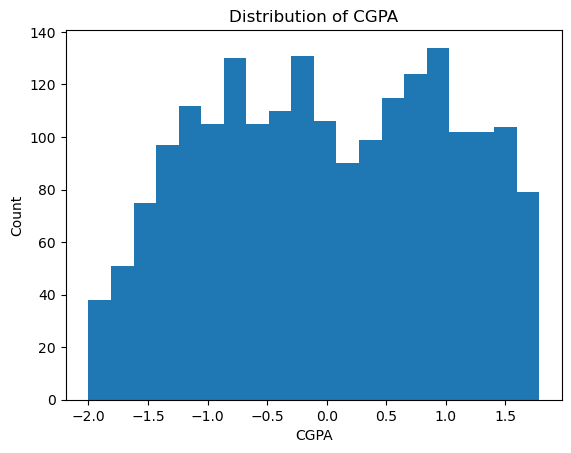

In [44]:
# Distribution of CGPA
plt.hist(df["CGPA"], bins=20)
plt.title("Distribution of CGPA")
plt.xlabel("CGPA")
plt.ylabel("Count")
plt.show()


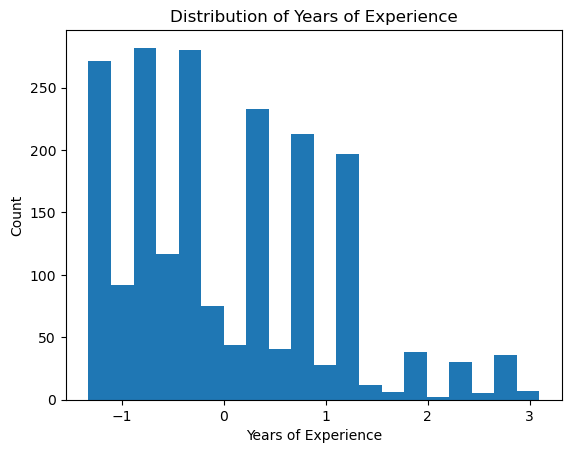

In [45]:
# Distribution of Years of Experience

plt.hist(df["Years of Experience"], bins=20)
plt.title("Distribution of Years of Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Count")
plt.show()


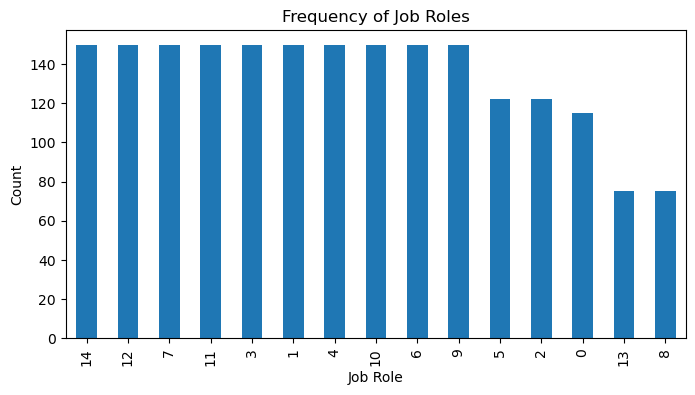

In [46]:
# Job Role Count Plot

df["Job Role"].value_counts().plot(kind="bar", figsize=(8,4))
plt.title("Frequency of Job Roles")
plt.xlabel("Job Role")
plt.ylabel("Count")
plt.show()


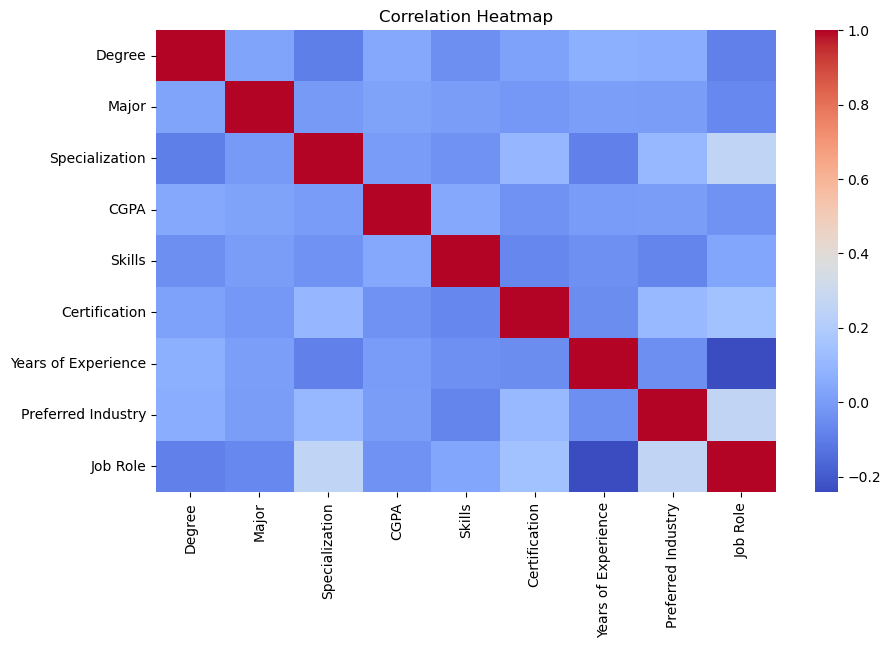

In [47]:
# Correlation Heatmap

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
